# 03 — Signal Construction (All 4 Jump Definitions)

Compute D1, D2, D3, D4 jump signals for every prediction market.
Output a summary table and save signal parquets.

**Outputs**:
- `data/processed/jump_signals_D1.parquet`
- `data/processed/jump_signals_D2.parquet`
- `data/processed/jump_signals_D3.parquet`
- `data/processed/jump_signals_D4.parquet`
- Printed summary table: signal counts per market × definition

In [1]:
import sys
sys.path.append('..')

import importlib
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Force reload src.signal so any fixes in fetch session are picked up
import src.signal as _signal_mod
importlib.reload(_signal_mod)
from src.signal import compute_all_signals, signal_summary

import src.plots as _plots_mod
importlib.reload(_plots_mod)
from src.plots import plot_probability_series

with open('../config.yaml') as f:
    cfg = yaml.safe_load(f)

raw_dir  = Path('../data/raw')
proc_dir = Path('../data/processed')

prob_df = pd.read_parquet(proc_dir / 'prob_mid_aligned.parquet')
final_markets = pd.read_parquet(raw_dir / 'kalshi' / 'final_market_list.parquet')
print(f'Markets: {prob_df.shape[1]}, Bars: {len(prob_df):,}')

Markets: 53, Bars: 416,225


## Compute All 4 Definitions for Each Market

In [2]:
all_signals  = {'D1': {}, 'D2': {}, 'D3': {}, 'D4': {}}
summary_rows = []

for ticker in prob_df.columns:
    prob_mid = prob_df[ticker].dropna()
    if len(prob_mid) < 100:
        print(f'  {ticker}: too few bars, skipping')
        continue

    # Load volume for D4 — deduplicate, align to prob_mid index, coerce to numeric
    raw_path = raw_dir / 'kalshi' / f'{ticker}.parquet'
    volume = None
    if raw_path.exists():
        raw_df = pd.read_parquet(raw_path).set_index('timestamp_utc').sort_index()
        raw_df = raw_df[~raw_df.index.duplicated(keep='first')]
        if 'volume' in raw_df.columns:
            volume = pd.to_numeric(raw_df['volume'], errors='coerce').reindex(prob_mid.index)

    signals = compute_all_signals(prob_mid, volume=volume, cfg=cfg)

    for defn, sig_df in signals.items():
        all_signals[defn][ticker] = sig_df['signal']

    summary = signal_summary(signals, market_id=ticker)
    summary_rows.append(summary)

    counts = ', '.join(f"{d}={signals[d]['signal'].ne(0).sum()}" for d in signals)
    print(f'  {ticker}: {counts}')

summary_df = pd.concat(summary_rows, ignore_index=True)
print(f'\nDone. {len(all_signals["D1"])} markets processed.')

  KXBTCMAXY-25-DEC31-129999.99: D1=88, D2=5, D3=36, D4=67
  KXBTCMAXY-25-DEC31-139999.99: D1=77, D2=4, D3=45, D4=61
  KXBTCMAX150-25-26MAY31-149999.99: D1=56, D2=4, D3=12, D4=30
  KXBTCMAX150-25-26MAR31-149999.99: D1=62, D2=5, D3=37, D4=44
  KXBTCMAX150-25-26APR30-149999.99: D1=45, D2=3, D3=22, D4=30
  KXBTCMAX150-25-26FEB28-149999.99: D1=81, D2=10, D3=18, D4=50
  KXBTCMAX100-26-MAR: D1=60, D2=11, D3=35, D4=31
  KXBTCMAX150-25-26JAN31-149999.99: D1=67, D2=14, D3=20, D4=37
  KXBTCMAX100-26-FEB: D1=76, D2=14, D3=40, D4=45
  KXBTCMAX100-26-APR: D1=54, D2=12, D3=27, D4=30
  KXBTCMAXY-25-DEC31-149999.99: D1=143, D2=27, D3=26, D4=123
  KXBTCMAX150-25-DEC31-149999.99: D1=129, D2=23, D3=23, D4=112
  KXBTCMAX100-26-JUNE: D1=106, D2=15, D3=9, D4=51
  KXBTCMAXY-26DEC31-99999.99: D1=37, D2=5, D3=1, D4=34
  KXBTCMAX100-26-MAY: D1=61, D2=14, D3=4, D4=26
  KXBTCMAXY-25-DEC31-199999.99: D1=35, D2=6, D3=31, D4=23
  KXBTCMAXY-25-DEC31-169999.99: D1=27, D2=10, D3=27, D4=18
  KXBTCMAXY-25-DEC31-159999.99:

## Signal Count Summary Table

In [3]:
print('=== Signal Count Summary ===')
pivot = summary_df.pivot(index='market', columns='definition', values='n_total')
print(pivot.to_string())

print('\n=== Markets with INSUFFICIENT signals (< 30) per definition ===')
insufficient = summary_df[~summary_df['sufficient_for_inference']]
if insufficient.empty:
    print('  All markets have >= 30 signals for all definitions.')
else:
    print(insufficient[['market', 'definition', 'n_total']].to_string(index=False))

=== Signal Count Summary ===
definition                         D1  D2  D3   D4
market                                            
KXBTCMAX100-26-APR                 54  12  27   30
KXBTCMAX100-26-DEC                 26   1   1   13
KXBTCMAX100-26-FEB                 76  14  40   45
KXBTCMAX100-26-JUNE               106  15   9   51
KXBTCMAX100-26-MAR                 60  11  35   31
KXBTCMAX100-26-MAY                 61  14   4   26
KXBTCMAX100-26-SEP                 19   3   3   11
KXBTCMAX150-25-26APR30-149999.99   45   3  22   30
KXBTCMAX150-25-26FEB28-149999.99   81  10  18   50
KXBTCMAX150-25-26JAN31-149999.99   67  14  20   37
KXBTCMAX150-25-26MAR31-149999.99   62   5  37   44
KXBTCMAX150-25-26MAY31-149999.99   56   4  12   30
KXBTCMAX150-25-DEC31-149999.99    129  23  23  112
KXBTCMAXY-25-DEC31-129999.99       88   5  36   67
KXBTCMAXY-25-DEC31-139999.99       77   4  45   61
KXBTCMAXY-25-DEC31-149999.99      143  27  26  123
KXBTCMAXY-25-DEC31-159999.99      101  17  32   81
KX

## Save Signal Parquets

Each parquet has a MultiIndex of (market_id, timestamp_utc) with the signal column.

In [4]:
proc_dir.mkdir(parents=True, exist_ok=True)

for defn, market_signals in all_signals.items():
    if not market_signals:
        continue

    # Stack all markets into one DataFrame: columns = market tickers, index = timestamp_utc
    combined = pd.DataFrame(market_signals)
    combined.index.name = 'timestamp_utc'

    out_path = proc_dir / f'jump_signals_{defn}.parquet'
    combined.to_parquet(out_path)
    n_events = (combined != 0).sum().sum()
    print(f'  {defn}: saved {combined.shape[1]} markets, {int(n_events)} total events → {out_path.name}')

  D1: saved 53 markets, 19892512 total events → jump_signals_D1.parquet
  D2: saved 53 markets, 19890837 total events → jump_signals_D2.parquet
  D3: saved 53 markets, 19891093 total events → jump_signals_D3.parquet
  D4: saved 53 markets, 19891542 total events → jump_signals_D4.parquet


## Visualize: Signal Distribution for Each Definition

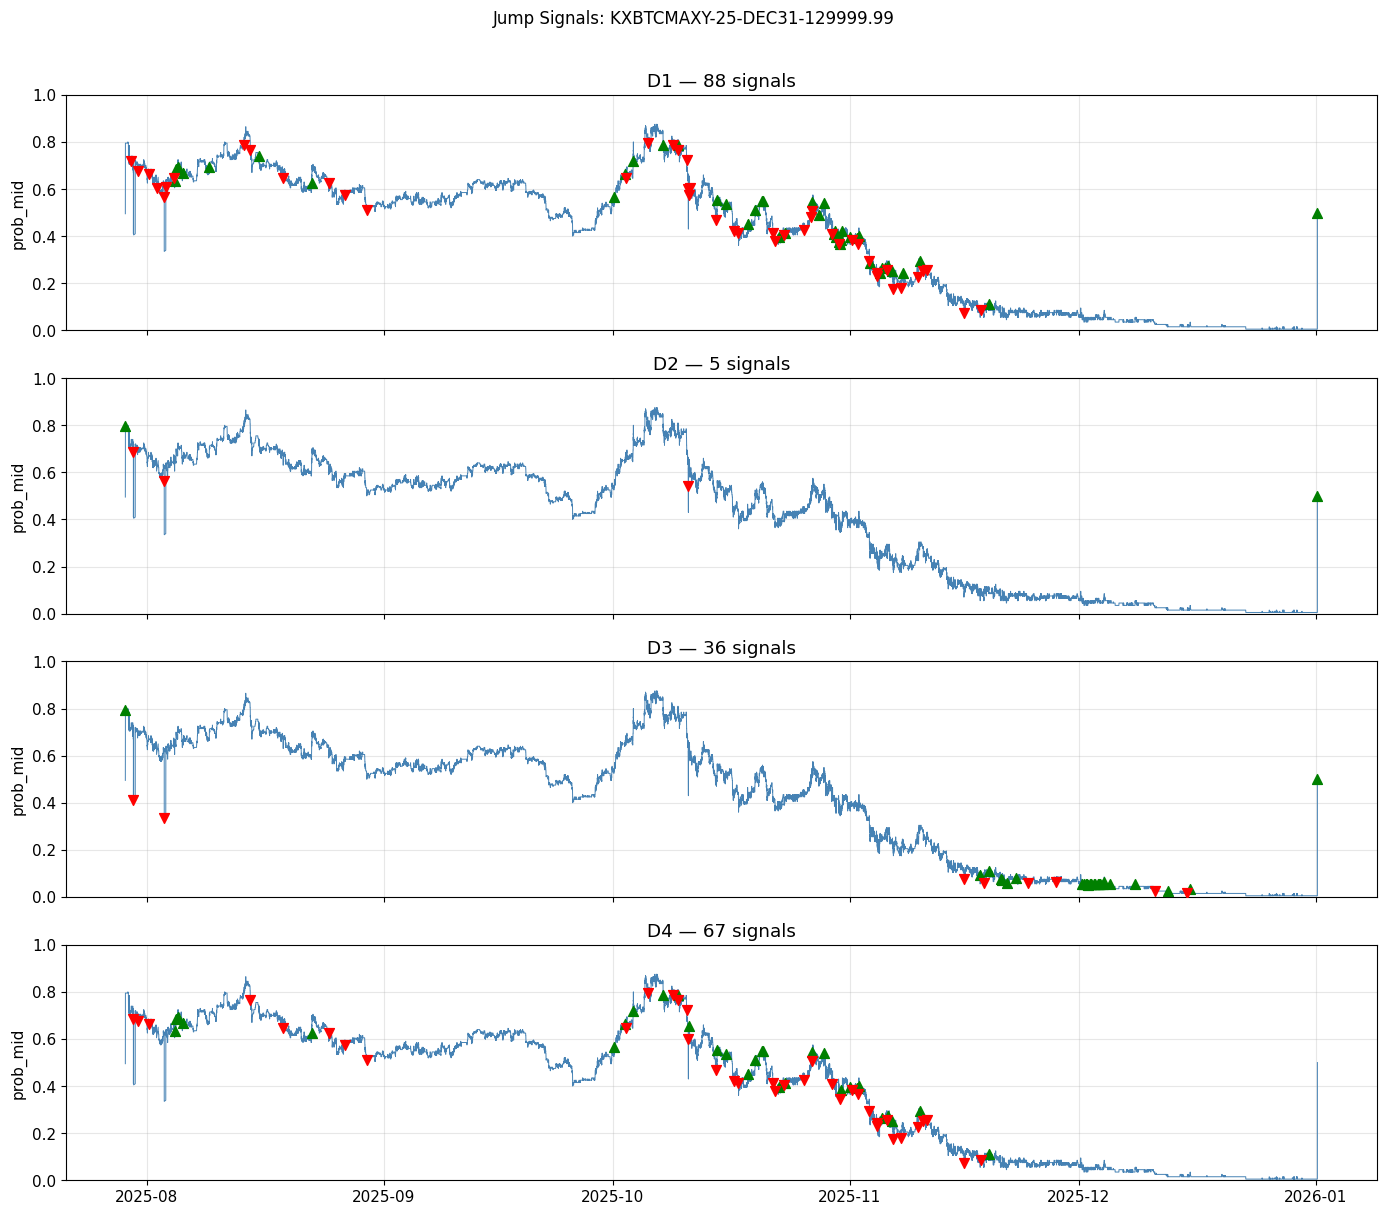

In [5]:
# For one example market, show how each definition fires differently
example_ticker = prob_df.columns[0]

raw_path = raw_dir / 'kalshi' / f'{example_ticker}.parquet'
volume = None
if raw_path.exists():
    raw_df = pd.read_parquet(raw_path).set_index('timestamp_utc').sort_index()
    raw_df = raw_df[~raw_df.index.duplicated(keep='first')]
    if 'volume' in raw_df.columns:
        volume = pd.to_numeric(raw_df['volume'], errors='coerce')

prob_mid = prob_df[example_ticker].dropna()

if len(prob_mid) > 100:
    sigs = compute_all_signals(prob_mid, volume=volume, cfg=cfg)

    fig, axes = plt.subplots(len(sigs), 1, figsize=(14, 3 * len(sigs)), sharex=True)
    ax_list = axes if len(sigs) > 1 else [axes]
    for ax, (defn, sig_df) in zip(ax_list, sigs.items()):
        ax.plot(prob_mid.index, prob_mid.values, lw=0.7, color='steelblue')
        events = sig_df[sig_df['signal'] != 0]
        up = events[events['signal'] == 1]
        dn = events[events['signal'] == -1]
        ax.scatter(up.index, prob_mid.reindex(up.index), marker='^', color='green', s=50, zorder=5)
        ax.scatter(dn.index, prob_mid.reindex(dn.index), marker='v', color='red',   s=50, zorder=5)
        ax.set_title(f'{defn} — {len(events)} signals')
        ax.set_ylabel('prob_mid')
        ax.set_ylim(0, 1)

    plt.suptitle(f'Jump Signals: {example_ticker}', y=1.01, fontsize=12)
    plt.tight_layout()
    plt.show()